In [24]:
# Nós --> Nós escolhemos quantos grupos (k)
# K-Means --> Cria os grupos com base na distância aos centroides
# Cotovelo --> Ajuda a escolher o k analisando a inércia (Erro = Distância dos pontos aos centroides)
# Silhouette --> Avalia se os grupos estão •bem separados e •bem formados
# StandardScaler --> Normaliza os dados usando z-score (média=0; desvio=1)
# PCA --> Reduz a dimensionalidade dos dados para facilitar a visualização em 2D
# Heatmap de Correlação --> Mostra relações •positivas e •negativas entre os tipos de crime
# Apriori --> Encontra combinações frequentes de crimes que ocorrem juntos
# Regras de Associação --> Cria relações do tipo "Se A acontece, então B tende a acontecer"
# Support --> Mede •a frequência de uma combinação •no conjunto de dados
# Confidence --> Mede a probabilidade de B ocorrer dado que A ocorreu
# Lift --> Mede se a associação entre A e B é •real ou •apenas coincidência
# Pivot Table --> Reorganiza os dados em formato Cidade X Tipo de crime
# Binarização --> Converte ocorrência em presença/ausência (1/0 ou True/False)
# Cluster --> Grupo de cidades com perfil criminal semelhante
# Centróide --> Centro matemático de um cluster
# Inércia --> •Soma das distâncias dos pontos •até o centróide do próprio cluster
# Correlação --> Mede •o grau de relação linear •entre dois tipos de crime

In [25]:
####### CRIMINALIDADE EM CIDADES DE SÃO PAULO

# @@@ Importação das bibliotecas

import pandas as pd # Manipula tabelas de dados
import numpy as np # Faz cálculos matemáticos
import seaborn as sns # Cria gráficos
import matplotlib.pyplot as plt # Cria gráficos

from sklearn.preprocessing import StandardScaler # Normaliza os dados (faz com que as colunas tenham peso "parecido”)
from sklearn.cluster import KMeans # Cria clusters (agrupamentos)
from sklearn.metrics import cluster, silhouette_score # Avalia a qualidade dos clusters (separação entre eles)
from sklearn.decomposition import PCA # Reduz a dimensionalidade dos dados para visualização em 2D
from mlxtend.frequent_patterns import apriori # Encontra padrões frequentes (combinações de crimes que ocorrem juntos)
from mlxtend.frequent_patterns import association_rules # Encontra padrões frequentes ("Se há furto, então há roubo.")

# @@@ Leitura dos arquivo

df = pd.read_excel('arquivo.xlsx') # Lê o arquivo que contém os dados

# @@@ Informações básicas sobre a base de dados

print("=" * 50)
print("INFORMAÇÕES DA BASE DE DADOS")
print("=" * 50)
print(f"Total de registros : {df.shape[0]}") # Quantidade de linhas (cidades x tipos de crime) (elemento 0)
print(f"Total de atributos : {df.shape[1]}") # Quantidade de colunas (cidade, natureza, meses numéricos...) (elemento 1)
print(f"Cidades únicas     : {df['cidade'].nunique()}") # "number of unique" --> Quantidade de valores únicos (sem repetir)
print(f"Tipos de crime     : {df['natureza'].nunique()}") # "number of unique" --> Quantidade de valores únicos (sem repetir)
print(f"\nAtributos:\n{df.dtypes}") # Tipo de dado de cada coluna (object = texto; int64 = número inteiro; float64 = número decimal)
print("\nPrimeiras linhas:")
print(df.head()) # Por padrão, mostra as 5 primeiras linhas da tabela

# @@@ Coluna dos meses (1 a 12)

meses = list(range(1, 13))

# @@@ Cria total anual por registro

df['total_anual'] = df[meses].sum(axis=1) # Soma todos os meses de cada registro (linha)

print("\nTOTAL ANUAL CALCULADO:")
print(df[['cidade', 'natureza', 'total_anual']].head()) # Destas colunas, mostra as primeiras 5 linhas (por padrão)

INFORMAÇÕES DA BASE DE DADOS
Total de registros : 1196
Total de atributos : 15
Cidades únicas     : 52
Tipos de crime     : 23

Atributos:
ordem_id     int64
cidade      object
natureza    object
1            int64
2            int64
3            int64
4            int64
5            int64
6            int64
7            int64
8            int64
9            int64
10           int64
11           int64
12           int64
dtype: object

Primeiras linhas:
   ordem_id cidade                                           natureza  1  2  \
0         1  aguai                                   homicidio_doloso  0  1   
1         2  aguai              numero_de_vitimas_em_homicidio_doloso  0  1   
2         3  aguai          homicidio_doloso_por_acidente_de_transito  0  0   
3         4  aguai  numero_de_vitimas_em_homicidio_doloso_por_acid...  0  0   
4         5  aguai         homicidio_culposo_por_acidente_de_transito  0  0   

   3  4  5  6  7  8  9  10  11  12  
0  0  0  0  0  0  0  0   0   0 

In [26]:
# @@@@@@@@@@@@@@
# @@@ Remove colunas de contagem de vítimas (pré-processamento de dados)
# @@@@@@@@@@@@@@

naturezas_remover = [
    'numero_de_vitimas_em_homicidio_doloso',
    'numero_de_vitimas_em_homicidio_doloso_por_acidente_de_transito',
    'numero_de_vitimas_em_latrocinio',
    'total_de_estupro',
    'total_de_roubos_outros'
]





df_filtrado = df[~df['natureza'].isin(naturezas_remover)].copy()
# Cria uma nova tabela sem as linhas de "natureza_remover"
# Tira da coluna "natureza" tudo o que estiver especificado em "natureza_remover"

print(f"\nNaturezas utilizadas ({df_filtrado['natureza'].nunique()}):")
print(sorted(df_filtrado['natureza'].unique()))

# @@@ Pivot Table (cidades X tipos de crime)

pivot = df_filtrado.pivot_table(                    # Piracicaba    10 crimes 1º semestre
    index='cidade',                                 # Piracicaba    20 crimes 2º semestre
    columns='natureza',                             # Araras         5 crimes 1º semestre
    values='total_anual',                           # Araras        35 crimes 2º semestre
    aggfunc='sum', # Soma os totais anuais
    fill_value=0 # Preenche com 0 se estiver vazio  # Piracicaba    30 crimes anual
)                                                   # Araras        40 crimes anual
                                            
print("\nBASE PIVOTADA (cidades x crimes):")
print(f"Dimensão: {pivot.shape}") # Quantidade de linhas (cidades) x quantidade de colunas (tipos de crime)
print(pivot.head()) # Mostra as primeiras 5 linhas da tabela pivotada (cidades x tipos de crime)


Naturezas utilizadas (18):
['estupro', 'estupro_de_vulneravel', 'furto_de_veiculos', 'furto_outros', 'homicidio_culposo_outros', 'homicidio_culposo_por_acidente_de_transito', 'homicidio_doloso', 'homicidio_doloso_por_acidente_de_transito', 'latrocinio', 'lesao_corporal_culposa_outras', 'lesao_corporal_culposa_por_acidente_de_transito', 'lesao_corporal_dolosa', 'lesao_corporal_seguida_de_morte', 'roubo_a_banco', 'roubo_de_carga', 'roubo_de_veiculo', 'roubo_outros', 'tentativa_de_homicidio']

BASE PIVOTADA (cidades x crimes):
Dimensão: (52, 18)
natureza            estupro  estupro_de_vulneravel  furto_de_veiculos  \
cidade                                                                  
aguai                     2                     10                  9   
aguas_da_prata            0                      1                  6   
aguas_de_sao_pedro        0                      1                  3   
americana                15                     33                564   
analandia   

In [27]:
# @@@@@@@@@@@@@@
# @@@ Normalização dos dados (pré-processamento para K-Means)
# @@@@@@@@@@@@@@

# Técnica --> StandardScaler (média=0; desvio=1)
# Justificativa --> Os tipos de crime têm escalas muito diferentes
# Exemplo --> "furto_outros" tem centenas de ocorrências ao passo que "latrocinio" tem próximo a 0.
# No K-Means, a normalização não permite que variáveis de escala alta dominem as de escala menor

scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(pivot)

c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

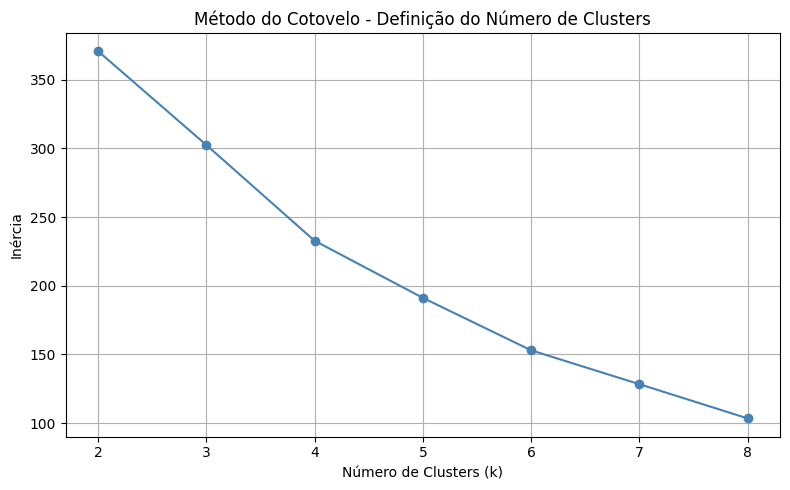

In [28]:
# @@@@@@@@@@@@@@
# @@@ Método do cotovelo
# @@@@@@@@@@@@@@

# Justificativa --> Identificar o k (nº de clusters) onde a queda de inércia COMEÇA a desacelerar ("cotovelo")

inercias = [] # inercia --> Aqui, é a soma das distâncias de todos os pontos até o centro do seu cluster
K = range(2, 9) # Estão sendo testados os k = 2, 3, 4, 5, 6, 7, 8

for k in K: # Para cada k da lista K, •o modelo é treinado e •a inércia é calculada e armazenada na lista "inercias"
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    # n_clusters=k --> Define o número de clusters a serem testados
    # random_state=42 --> “Use a sequência aleatória identificada por 42." (poderia ser qualquer outro número)
    # n_init=10:
    #    •Executa o algoritmo 10 vezes com diferentes centroides iniciais e escolhe a melhor solução
    #    •Isso aumenta a chance de encontrar um bom agrupamento, evitando soluções ruins causadas por centroides iniciais ruins
    modelo.fit(dados_normalizados) # •Analisa os dados •Cria os clusters •Encontra o centro de cada grupo
    inercias.append(modelo.inertia_)
    # Pega a inércia do modelo depois do treinamento
    # A inércia mede o quão longe os pontos estão do centro do próprio cluster

plt.figure(figsize=(8, 5)) # Define o tamanho do gráfico (largura x altura)
plt.plot(K, inercias, marker='o', color='steelblue') # •Faz o gráfico de linha (x = K; y = inercias) •"o" como marcadores •Cor azul
plt.title('Método do Cotovelo - Definição do Número de Clusters') # Título do gráfico
plt.xlabel('Número de Clusters (k)') # Rótulo do eixo x
plt.ylabel('Inércia') # Rótulo do eixo y
plt.grid(True) # Adiciona uma grade ao gráfico
plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos (Tight = Apertado, justo, compacto)
plt.savefig('grafico_cotovelo.png', dpi=150) # Salva o gráfico como "grafico_cotovelo.png" com resolução de 150 dpi (pontos por polegada)
plt.show() # Exibe o gráfico na tela

In [29]:
# @@@@@@@@@@@@@@
# @@@ Silhueta para múltiplos k
# @@@@@@@@@@@@@@

# Justificativa --> Complementa o cotovelo validando •a coesão interna e •a separação entre clusters
# Quanto mais próximo de 1, melhor a separação
# O pico do gráfico representa o valor de k (nº de clusters) com melhor equilíbrio entre coesão e separação entre os clusters testados

print("\nSILHOUETTE SCORE POR NÚMERO DE CLUSTERS:")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # n_clusters=k --> Define o número de clusters a serem testados
    # random_state=42 --> “Use a sequência aleatória identificada por 42." (poderia ser qualquer outro número)
    # n_init=10:
    #    •Executa o algoritmo 10 vezes com diferentes centroides iniciais e escolhe a melhor solução
    #    •Isso aumenta a chance de encontrar um bom agrupamento, evitando soluções ruins causadas por centroides iniciais ruins
    labels = km.fit_predict(dados_normalizados)
    # fit --> Encontra os centros dos clusters
    # predict --> Atribui cada ponto ao cluster mais próximo
    # labels --> Rótulos dos clusters para cada ponto (cidade)
    score = silhouette_score(dados_normalizados, labels)
    # silhouette_score(X, labels):
    #    •Mede a qualidade dos clusters
    #    •Encontra o ponto de equilíbrio entre ♦coesão e ♦separação dos clusters
    print(f"  k={k} → Silhouette Score: {score:.4f}") # Mostra o valor atual de k com 4 casas decimais


SILHOUETTE SCORE POR NÚMERO DE CLUSTERS:
  k=2 → Silhouette Score: 0.7299
  k=3 → Silhouette Score: 0.5195
  k=4 → Silhouette Score: 0.5621
  k=5 → Silhouette Score: 0.5997
  k=6 → Silhouette Score: 0.6172
  k=7 → Silhouette Score: 0.6125
  k=8 → Silhouette Score: 0.5332


c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

In [30]:
# @@@@@@@@@@@@@@
# @@@ K-Means final --> Entre os k(2, 3, 4, 5, 6, 7, 8) testados, escolhe o k de maior equilíbrio (aqui, k = 3)
# @@@@@@@@@@@@@@

# Justificativa --> k final foi escolhido com base no cotovelo e no silhouette score
# Pode ser humanamente interpretado como:
#    ♦ VERDE --> Baixa Criminalidade
#    ♦ AMARELO --> Média Criminalidade
#    ♦ VERMELHO --> Alta Criminalidade

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(dados_normalizados)
pivot['cluster'] = clusters

c:\Users\paulo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:
# @@@@@@@@@@@@@@
# @@@ Silhouette Score Final --> Avalia a qualidade do agrupamento final (aqui, k = 3)
# @@@@@@@@@@@@@@

# Justificativa --> Fornece uma métrica objetiva para avaliar a separação entre os clusters formados

silhouette = silhouette_score(dados_normalizados, clusters) # •Eixo x --> Dados normalizados •Eixo y --> Rótulos dos clusters
print(f"\nSILHOUETTE SCORE FINAL (k = 3): {silhouette:.4f}")





print("Referência escolhida neste momento: >0.50 = Boa separação | 0.25–0.50 = Razoável")


SILHOUETTE SCORE FINAL (k = 3): 0.5195
Referência escolhida neste momento: >0.50 = Boa separação | 0.25–0.50 = Razoável


In [32]:
# @@@@@@@@@@@@@@
# @@@ PCA PARA VISUALIZAÇÃO 2D --> É como se fossem coordenadas para plotar pontos (aqui, cidades) em um gráfico de dispersão
# @@@@@@@@@@@@@@

# PCA:
#    •Principal Component Analysis (Análise de Componentes Principais)
#    •Justificativa --> Para facilitar a visualização, reduz a dimensionalidade dos dados

pca = PCA(n_components=2) # Reduz a dimensionalidade de n variáveis para poucos componentes (aqui, 2)
componentes = pca.fit_transform(dados_normalizados) # Converte os dados originais em um sistema de coordenadas (PC1, PC2...)


variancia = pca.explained_variance_ratio_
# Quanto cada componente (PC1, PC2...) consegue explicar da variação dos dados originais
print(f"\nVariância explicada pelo PCA:")
print(f"  PC1: {variancia[0]*100:.1f}%") # --> PC1 é o componente que mais explica a variação dos dados originais
print(f"  PC2: {variancia[1]*100:.1f}%") # --> PC2 é o segundo componente mais importante, explicando a variação restante
print(f"  Total: {sum(variancia)*100:.1f}%") # --> Total da variação explicada pelos 2 componentes (PC1 + PC2)


Variância explicada pelo PCA:
  PC1: 69.3%
  PC2: 8.5%
  Total: 77.8%


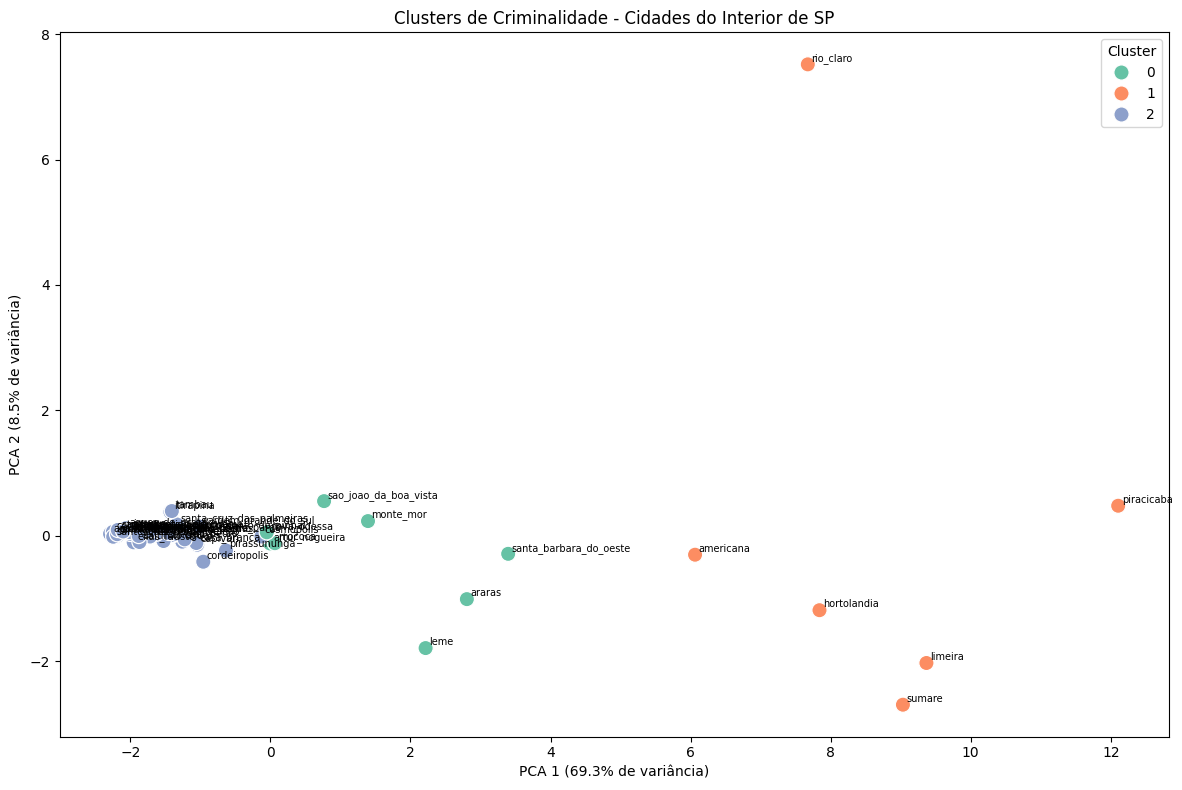

In [33]:
# @@@@@@@@@@@@@@
# @@@ GRÁFICO DOS CLUSTERS
# @@@@@@@@@@@@@@

plt.figure(figsize=(12, 8)) # Define o tamanho do gráfico (Largura X Altura)
sns.scatterplot( # Cria um gráfico de dispersão
    x=componentes[:, 0], # Coordenada X dos pontos (PC1)
    y=componentes[:, 1], # Coordenada Y dos pontos (PC2)
    hue=clusters, # Cor dos pontos com base nos clusters
    palette='Set2', # Paleta de cores
    s=120 # Tamanho dos pontos
)

for i, cidade in enumerate(pivot.index): # Para cada cidade, pega •o nome da cidade e •as coordenadas (PC1, PC2)
    plt.text( # Adiciona •o nome da cidade •próximo ao ponto correspondente
        componentes[i, 0] + 0.05, # Ajusta a posição do texto para não sobrepor o ponto (PC1 + 0.05)
        componentes[i, 1] + 0.05, # Ajusta a posição do texto para não sobrepor o ponto (PC2 + 0.05)
        cidade, fontsize=7 # Tamanho da fonte do nome da cidade
    )

plt.title('Clusters de Criminalidade - Cidades do Interior de SP') # Título do gráfico
plt.xlabel(f'PCA 1 ({variancia[0]*100:.1f}% de variância)') # Rótulo do eixo x com a porcentagem de variação explicada pelo PC1
plt.ylabel(f'PCA 2 ({variancia[1]*100:.1f}% de variância)') # Rótulo do eixo y com a porcentagem de variação explicada pelo PC2
plt.legend(title='Cluster') # Adiciona uma legenda para os clusters
plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos (Tight = Apertado, justo, compacto)
plt.savefig('grafico_clusters.png', dpi=150) # Salva o gráfico como "grafico_clusters.png" com resolução de 150 dpi (pontos por polegada)
plt.show() # Exibe o gráfico na tela

In [34]:
# @@@@@@@@@@@@@@
# @@@ Análise dos clusters
# @@@@@@@@@@@@@@

print("\nCIDADES POR CLUSTER:")
for c in sorted(pivot['cluster'].unique()):
# Para cada cluster único (c) ♦encontrado na coluna "cluster" da tabela pivotada e ♦ordenados de forma crescente
    cidades = pivot[pivot['cluster'] == c].index.tolist()
    # pivot['cluster'] == c
    #    •Cria uma condição booleana (True/False) (ou 0 ou 1)
    #    •"Essa lilha pertence ao cluster 0???" Resposta --> OU True (sim) OU False (não)
    #    •Verifica se o valor da coluna 'cluster' é igual à variável c para cada linha da tabela pivotada
    #    •Pivotar --> Transformar linhas em colunas e colunas em linhas
    # pivot[pivot['cluster'] == c] --> Filtra a tabela mantendo apenas as linhas onde o cluster é igual a c (0, 1 ou 2)
    # .index --> Pega os índices de cada linha (Se o índice da tabela pivotada for o nome das cidades, então Index(['SP', 'BH'])
    #.tolist() --> Converte o índice em uma lista Python comum ['SP', 'BH']
    print(f"\n  Cluster {c} ({len(cidades)} cidades):")
    # Cluster {c} --> 0, 1 ou 2
    # len(cidades) --> Cidades que pertencem a cada cluster
    print(f"  {', '.join(cidades)}") # Imprime a lista de cidades de cada cluster (cidades separadas por vírgula) (join = juntar)

cols_crimes = [c for c in pivot.columns if c != 'cluster'] # Cria uma lista com os nomes das colunas de crimes (salvo a coluna "cluster")

print("\nMÉDIA DOS CRIMES POR CLUSTER:")
analise_clusters = pivot.groupby('cluster')[cols_crimes].mean().round(2)
# pivot.groupby('cluster') --> Agrupa as cidades pela coluna 'cluster' (todas as cidades de 0, 1 e 2)
# [cols_crimes].mean().round(2) --> Calcula a média (.mean()) de cada crime dentro de cada cluster (usa duas casas decimais)

print(analise_clusters.T) # T --> Transpor (Linhas <--> Colunas) para facilitar a leitura (crimes como linhas e clusters como colunas)


CIDADES POR CLUSTER:

  Cluster 0 (8 cidades):
  araras, artur_nogueira, leme, mococa, monte_mor, nova_odessa, santa_barbara_do_oeste, sao_joao_da_boa_vista

  Cluster 1 (6 cidades):
  americana, hortolandia, limeira, piracicaba, rio_claro, sumare

  Cluster 2 (38 cidades):
  aguai, aguas_da_prata, aguas_de_sao_pedro, analandia, brotas, caconde, capivari, casa_branca, charqueada, conchal, cordeiropolis, corumbatai, cosmopolis, divinolandia, elias_fausto, engenheiro_coelho, espirito_santo_do_pinhal, ipeuna, iracemapolis, itirapina, itobi, mombuca, pirassununga, rafard, rio_das_pedras, saltinho, santa_cruz_da_conceicao, santa_cruz_das_palmeiras, santa_gertrudes, santa_maria_da_serra, santo_antonio_do_jardim, sao_jose_do_rio_pardo, sao_pedro, sao_sebastiao_da_grama, tambau, tapiratiba, torrinha, vargem_grande_do_sul

MÉDIA DOS CRIMES POR CLUSTER:
cluster                                               0        1       2
natureza                                                              

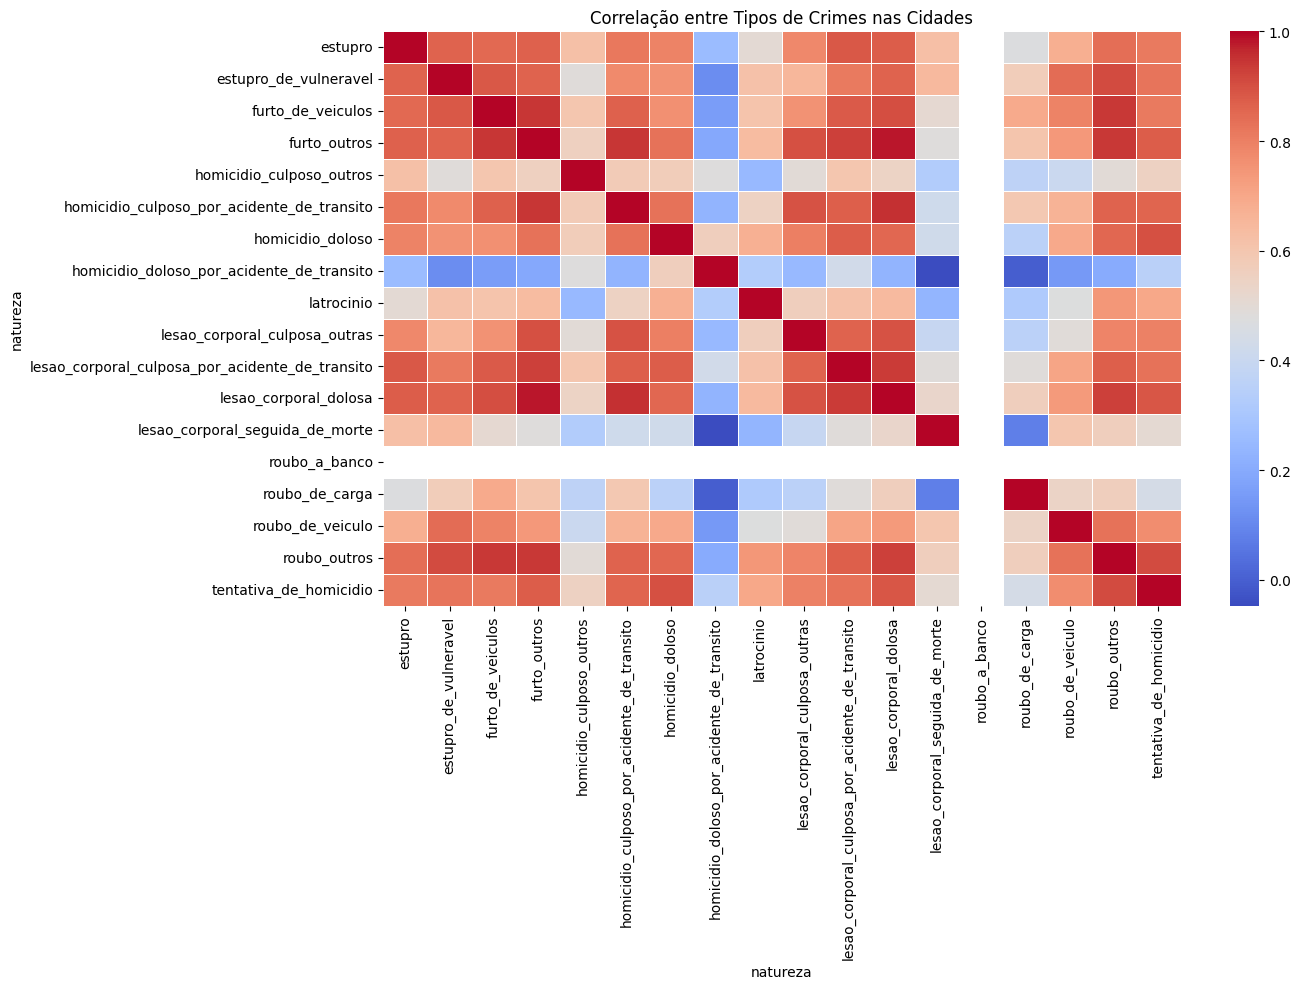

In [35]:
# @@@@@@@@@@@@@@
# @@@ Heatmap (Mapa de Calor) de Correlação
# @@@@@@@@@@@@@@

plt.figure(figsize=(14, 10)) # Define o tamanho do gráfico (Largura X Altura)
sns.heatmap( # Cria um mapa de calor
    pivot[cols_crimes].corr(), # pivot[cols_crimes] --> Pega só as colunas de crimes •.corr() --> Calcula a correlação entre elas
    cmap='coolwarm', # Define as cores da correlação --> •Azul (<0) •Branco (0) •Vermelho (>0)
    annot=False, # •True --> Mostra números (0.85, -0.30 etc.) •False --> Não mostra números (só cores) 
    linewidths=0.5 # Define a espessura das linhas que separam as células
)
plt.title('Correlação entre Tipos de Crimes nas Cidades') # Título do gráfico
plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos (Tight = Apertado, justo, compacto)
plt.savefig('heatmap_correlacao.png', dpi=150) # Salva o gráfico como "grafico_clusters.png" com resolução de 150 dpi (pontos por polegada)
plt.show() # Exibe o gráfico na tela

In [36]:
# @@@@@@@@@@@@@@
# @@@ Preparação para (o futuro) Apriori
# @@@@@@@@@@@@@@

# Justificativa --> Identificar quais tipos de crime tendem a ocorrer juntos na mesma cidade

df_binario = df_filtrado.copy() # Cria uma cópia da tabela filtrada para preparar os dados para o Apriori

# Binarizar: 1 se houve ao menos 1 ocorrência no ano
# Justificativa: Apriori exige dados binários (transacionais).
# A presença/ausência do crime por cidade é mais informativa do que a contagem absoluta aqui.
df_binario['ocorreu'] = np.where(df_binario['total_anual'] > 0, 1, 0)
# np.where() --> No caso acima, se uma coisa (aqui, df_binario['total_anual']) for maior que 0, então, 1; senão, 0

basket = df_binario.pivot_table( # Cria uma tabela onde...
    index='cidade', #... as linhas são as cidades
    columns='natureza', #... as colunas são os tipos de crime
    values='ocorreu', # ... e os valores são 1 (ocorreu) ou 0 (não ocorreu)
    aggfunc='max',
    # Se houver mais de um registro para a mesma cidade e tipo de crime, pega o valor máximo
    # •Valor máximo = 1 (se houve ocorrência) •Valor mínimo = 0 (se não houve ocorrência)
    fill_value=0 # Preenche com 0 se estiver vazio (ou seja, se estiver vazio, assume que não houve ocorrência)
)

# Converter para booleano (exigido pelo mlxtend)
basket = basket.astype(bool) # Para atender aos requisitos do Apriori, converte 1 e 0 para True e False, respectivamente
# mlxtend --> Biblioteca que possui implementações de:
#   •Apriori --> Encontra padrões frequentes (combinações de coisas que ocorrem juntas)
#   •Regras de associação --> "Se ha roubo, então há furto"
#   •Análise de "market basket" --> No mercado, o que as pessoas compram juntas??? (Aqui, quais crimes ocorrem juntos???)
#   •Métricas de:
#       ♦Suporte --> Frequência da combinação no dataset ("Furto e roubo juntos aparecem em 30% das cidades.")
#       ♦Confiança --> Probabilidade de B acontecer dado A ("Se tem furto, em 80% dos casos também tem roubo.")
#       ♦Lift --> Mede se a relação é real ou só coincidência ("Furto e roubo aparecem juntos mais vezes do que o esperado por acaso?")
#           •Interpretação --> •= 1 (sem relação) •> 1 (relação positiva) •< 1 (relação negativa)
#           •Exemplo --> •lift = 2 (muito associado) •lift = 0.5 (aparecem menos juntos do que esperado)

print("\nBASE BINÁRIA PARA APRIORI:")
print(f"Dimensão: {basket.shape}") # Quantidade de linhas (cidades) X Quantidade de colunas (tipos de crime)
print(basket.head()) # Mostra as primeiras 5 linhas da tabela binária (Cidades X Tipos de crime com True/False)


BASE BINÁRIA PARA APRIORI:
Dimensão: (52, 18)
natureza            estupro  estupro_de_vulneravel  furto_de_veiculos  \
cidade                                                                  
aguai                  True                   True               True   
aguas_da_prata        False                   True               True   
aguas_de_sao_pedro    False                   True               True   
americana              True                   True               True   
analandia              True                   True               True   

natureza            furto_outros  homicidio_culposo_outros  \
cidade                                                       
aguai                       True                     False   
aguas_da_prata              True                     False   
aguas_de_sao_pedro          True                     False   
americana                   True                      True   
analandia                   True                     False   

nature

In [37]:
# @@@@@@@@@@@@@@
# @@@ Algoritmo Apriori --> Encontra •padrões frequentes e •regras de associação entre os tipos de crime
# @@@@@@@@@@@@@@

# ALGORITMO APRIORI
# min_support=0.7 → crime deve aparecer em pelo menos 70% das cidades (~36 de 52).

# Justificativa: garante padrões robustos e # representativos, evitando regras raras ou espúrias. Valor testado empiricamente com
# suportes 0.3, 0.5, 0.6, 0.7 e 0.8.

# max_len=3 → limita itemsets (conjunto de itens) a 3 itens para gerar regras •interpretáveis e •em volume razoável.
# ==========================================

frequentes = apriori(
    basket, # Base de dados binária (Cidades X Tipos de crime com True/False)
    min_support=0.7, # Crime deve aparecer em pelo menos 70% das cidades (~36 de 52)
    use_colnames=True, # Usa os nomes das colunas (tipos de crime) em vez de índices numéricos nos resultados
    max_len=3 # O algoritmo vai considerar apenas combinações de até 3 itens
)

print(f"\nITEMSETS FREQUENTES ENCONTRADOS: {len(frequentes)}")
# frequentes --> Tabela que contém os itemsets (conjunto de itens)encontrados pelo Apriori
# len(frequentes) --> Conta quantos itemsets (conjunto de itens) foram encontrados

print(frequentes.sort_values('support', ascending=False).head(10))
# frequentes --> Tabela que contém os itemsets (conjunto de itens) encontrados pelo Apriori
# .sort_values('support', ascending=False): 
#     •Ordena os itemsets pela coluna 'support' (frequência)...
#     •De forma decrescente (do mais frequente para o menos frequente)
#     •.head(10) --> Mostra os 10 itemsets mais frequentes (com maior suporte) encontrados pelo Apriori


ITEMSETS FREQUENTES ENCONTRADOS: 168
      support                                           itemsets
38   1.000000              (lesao_corporal_dolosa, furto_outros)
37   1.000000  (furto_outros, lesao_corporal_culposa_por_acid...
3    1.000000                                     (furto_outros)
137  1.000000  (lesao_corporal_dolosa, furto_outros, lesao_co...
7    1.000000  (lesao_corporal_culposa_por_acidente_de_transito)
8    1.000000                            (lesao_corporal_dolosa)
51   1.000000  (lesao_corporal_dolosa, lesao_corporal_culposa...
22   0.961538  (lesao_corporal_culposa_por_acidente_de_transi...
1    0.961538                            (estupro_de_vulneravel)
85   0.961538  (furto_outros, lesao_corporal_culposa_por_acid...


In [38]:
# @@@@@@@@@@@@@@
# @@@ Regras de associação
# @@@@@@@@@@@@@@

# Justificativa --> Assegura alta confiabilidade preditiva das regras
# Regras com lift > 1 indicam associação real (não aleatória)

regras = association_rules( # Gera regras de associação a partir dos itemsets
    frequentes, # Tabela que contém os itemsets (conjunto de itens) encontrados pelo Apriori
    metric='confidence', # Métrica usada para avaliar as regras (aqui, confiança)
    min_threshold=0.8, # Confiança mínima de 80%
    num_itemsets=len(frequentes)
    # Garante que todas as regras possíveis:
    #    •Sejam geradas a partir dos itemsets encontrados...
    #    •Sem limitar o número de regras
)

regras = regras[regras['lift'] > 1.0]
# Manter apenas as regras com lift > 1.0, ou seja:
#    •Regras que indicam uma associação real (não aleatória)...
#    •Entre os vários tipos de crime 

regras = regras.sort_values(by='lift', ascending=False)
# regras --> Tabela que contém as regras de associação geradas a partir dos itemsets
# sort_values --> Ordena a tabela com base em uma coluna (especificada em "by")
# by='lift' --> Especifica a coluna que será usada para ordenar a tabela (aqui, "lift")
# ascending=False --> Especifica a ordem da ordenação (aqui, não será em ordem crescente mas sim decrescente)

print(f"\nREGRAS DE ASSOCIAÇÃO GERADAS: {len(regras)}") # --> Conta as regras existentes na tabela regras
print("\nTOP 15 REGRAS (por Lift):\n")
print(
    regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']] # Pega apenas algumas colunas
    .head(15) # --> Mostra as 15 primeiras regras (com maior lift)
    .to_string(index=False) # --> Exibe a tabela sem os índices (sem a coluna de números à esquerda)
)


REGRAS DE ASSOCIAÇÃO GERADAS: 287

TOP 15 REGRAS (por Lift):

                                                        antecedents                                                         consequents  support  confidence     lift
                                           (tentativa_de_homicidio)          (roubo_outros, homicidio_culposo_por_acidente_de_transito) 0.711538    0.902439 1.203252
    (homicidio_culposo_por_acidente_de_transito, furto_de_veiculos)                                            (tentativa_de_homicidio) 0.711538    0.948718 1.203252
                                           (tentativa_de_homicidio)     (homicidio_culposo_por_acidente_de_transito, furto_de_veiculos) 0.711538    0.902439 1.203252
         (roubo_outros, homicidio_culposo_por_acidente_de_transito)                                            (tentativa_de_homicidio) 0.711538    0.948718 1.203252
                             (furto_outros, tentativa_de_homicidio)                        (homicidio_culpo

c:\Users\paulo\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [39]:
# @@@@@@@@@@@@@@
# @@@ Exportando os resultados
# @@@@@@@@@@@@@@

pivot.to_csv('clusters_resultado.csv', encoding='utf-8-sig')
# Salva a tabela pivot em um arquivo CSV chamado clusters_resultado.csv
regras.to_csv('regras_associacao.csv', encoding='utf-8-sig')
# Salva a tabela de regras em um arquivo CSV chamado regras_associacao.csv

print("\n" + "=" * 50)
print("ARQUIVOS EXPORTADOS COM SUCESSO!")
print("=" * 50)
print("- clusters_resultado.csv")
print("- regras_associacao.csv")
print("- grafico_cotovelo.png")
print("- grafico_clusters.png")
print("- heatmap_correlacao.png")


ARQUIVOS EXPORTADOS COM SUCESSO!
- clusters_resultado.csv
- regras_associacao.csv
- grafico_cotovelo.png
- grafico_clusters.png
- heatmap_correlacao.png


In [40]:
# @@@@@@@@@@@@@@
# @@@ Análise de outliers (Rio Claro - SP)
# @@@@@@@@@@@@@@

# Durante a visualização dos clusters (PCA):
#     •Rio Claro apareceu destacado dentro do Cluster 1 (alta criminalidade)...
#     •Sugerindo que é um outlier mesmo dentro do grupo dele

# Estratégia --> Calcular o Z-score de cada crime para Rio Claro

# Z-score --> Mede quantos desvios # padrão um valor está acima da média geral
#     •Z > 2 --> Outlier moderado
#     •Z > 3 --> Outlier severo

print("\n" + "=" * 50)
print("ANÁLISE DE OUTLIERS — RIO CLARO")
print("=" * 50)

pivot_norm = pd.DataFrame( # Z-scores normalizados de todas as cidades
    dados_normalizados,
    index=pivot.index,
    columns=cols_crimes
)

z_rio = pivot_norm.loc['rio_claro'].sort_values(ascending=False) # Z-scores específicos do Rio Claro

print("\nZ-SCORE DO RIO CLARO POR TIPO DE CRIME:")
print("(Valores > 2 indicam outlier em relação às demais cidades)\n")
print(z_rio.round(2).to_string())


outliers_rio = z_rio[z_rio > 2] # Destacar crimes com Z > 2
print(f"\nCrimes com Z-score > 2 (outliers severos): {len(outliers_rio)}")
for crime, z in outliers_rio.items():
    valor_real = pivot.loc['rio_claro', crime]
    media = pivot[crime].mean()
    print(f"  {crime}:")
    print(f"    Z-score = {z:.2f} | Rio Claro = {int(valor_real)} | Média geral = {media:.1f}")


ANÁLISE DE OUTLIERS — RIO CLARO

Z-SCORE DO RIO CLARO POR TIPO DE CRIME:
(Valores > 2 indicam outlier em relação às demais cidades)

homicidio_doloso_por_acidente_de_transito          7.14
homicidio_doloso                                   4.02
homicidio_culposo_outros                           3.40
lesao_corporal_culposa_por_acidente_de_transito    3.07
tentativa_de_homicidio                             2.51
latrocinio                                         2.36
estupro                                            1.85
lesao_corporal_culposa_outras                      1.79
homicidio_culposo_por_acidente_de_transito         1.65
lesao_corporal_dolosa                              1.65
roubo_outros                                       1.44
furto_outros                                       1.37
furto_de_veiculos                                  1.15
roubo_de_veiculo                                   1.04
estupro_de_vulneravel                              0.81
roubo_a_banco             

In [41]:
# @@@@@@@@@@@@@@
# @@@ Rio Claro X Média do cluster dele
# @@@@@@@@@@@@@@

cluster_rio = pivot.loc['rio_claro', 'cluster']
media_cluster = pivot[pivot['cluster'] == cluster_rio][cols_crimes].mean()
rio_valores = pivot.loc['rio_claro', cols_crimes]

comparacao = pd.DataFrame({
    'Rio Claro': rio_valores,
    'Média Cluster 1': media_cluster,
    'Ratio (RC / Cluster)': (rio_valores / media_cluster).round(2)
}).sort_values('Ratio (RC / Cluster)', ascending=False)

print(f"\nRIO CLARO vs MÉDIA DO CLUSTER {cluster_rio}:")
print(comparacao.round(2).to_string())


RIO CLARO vs MÉDIA DO CLUSTER 1:
                                                 Rio Claro  Média Cluster 1  Ratio (RC / Cluster)
natureza                                                                                         
homicidio_doloso_por_acidente_de_transito                1             0.17                  6.00
homicidio_culposo_outros                                 2             1.00                  2.00
homicidio_doloso                                        26            16.83                  1.54
lesao_corporal_culposa_por_acidente_de_transito        816           666.83                  1.22
latrocinio                                               1             0.83                  1.20
tentativa_de_homicidio                                  23            22.17                  1.04
estupro                                                 12            13.33                  0.90
lesao_corporal_culposa_outras                           17            19.67         

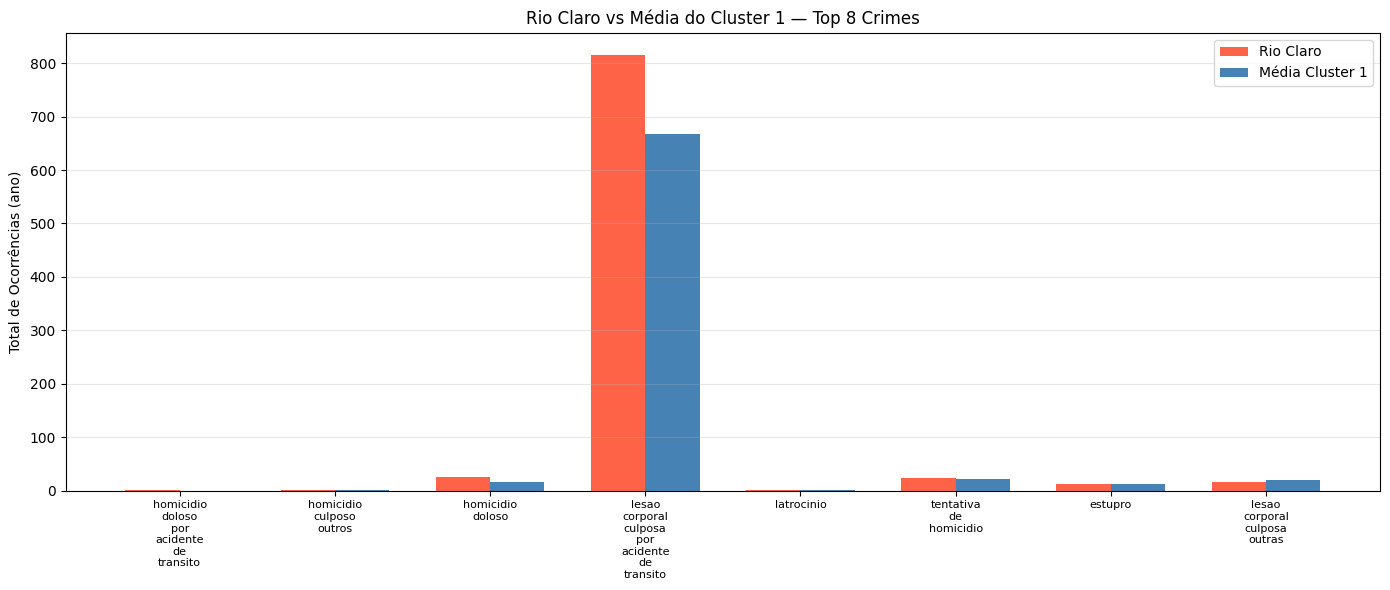

In [42]:
# @@@@@@@@@@@@@@
# @@@ Gráfico  --> Rio Claro X Média do cluster dele
# @@@@@@@@@@@@@@

top_crimes = comparacao.head(8).index.tolist()

x = range(len(top_crimes))
largura = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

barras1 = ax.bar(
    [i - largura/2 for i in x],
    comparacao.loc[top_crimes, 'Rio Claro'],
    largura,
    label='Rio Claro',
    color='tomato'
)
barras2 = ax.bar(
    [i + largura/2 for i in x],
    comparacao.loc[top_crimes, 'Média Cluster 1'],
    largura,
    label='Média Cluster 1',
    color='steelblue'
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [c.replace('_', '\n') for c in top_crimes],
    fontsize=8
)
ax.set_title('Rio Claro vs Média do Cluster 1 — Top 8 Crimes')
ax.set_ylabel('Total de Ocorrências (ano)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_rio_claro.png', dpi=150)
plt.show()

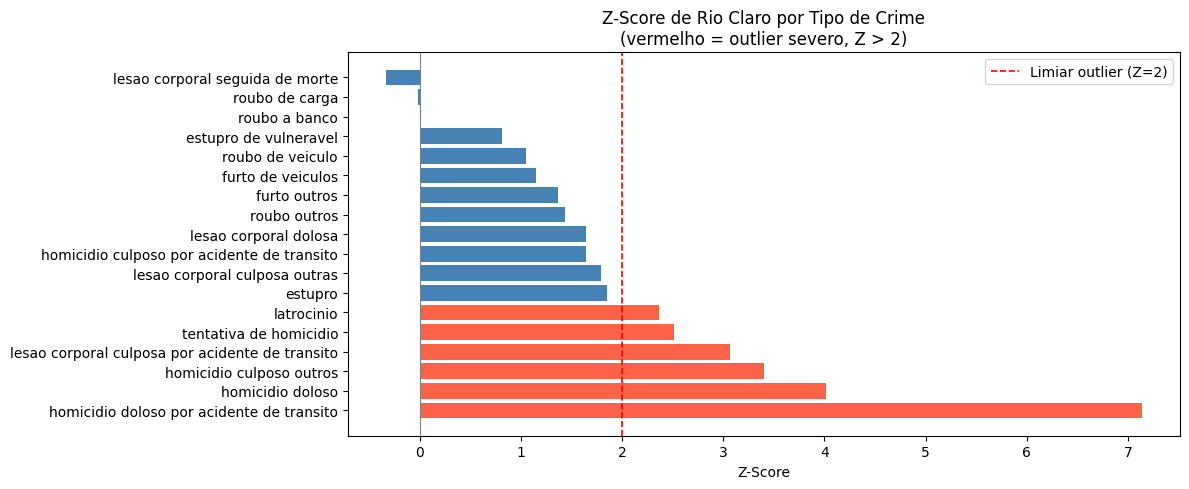


Arquivos gerados:
- outlier_rio_claro.png  → Rio Claro vs Cluster 1
- zscore_rio_claro.png   → Z-scores por crime


In [43]:
# @@@@@@@@@@@@@@
# @@@ Gráfico  --> Z-scores de Rio Claro
# @@@@@@@@@@@@@@

plt.figure(figsize=(12, 5))

cores = ['tomato' if z > 2 else 'steelblue' for z in z_rio.values]

plt.barh(
    [c.replace('_', ' ') for c in z_rio.index],
    z_rio.values,
    color=cores
)

plt.axvline(x=2, color='red', linestyle='--', linewidth=1.2, label='Limiar outlier (Z=2)')
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)

plt.title('Z-Score de Rio Claro por Tipo de Crime\n(vermelho = outlier severo, Z > 2)')
plt.xlabel('Z-Score')
plt.legend()
plt.tight_layout()
plt.savefig('zscore_rio_claro.png', dpi=150)
plt.show()

print("\nArquivos gerados:")
print("- outlier_rio_claro.png  → Rio Claro vs Cluster 1")
print("- zscore_rio_claro.png   → Z-scores por crime")